<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


<div style="background:linear-gradient(135deg,#2b2b2b,#4a1414); color:#f2eee6; padding:28px 32px; border-radius:12px; border-right:6px solid #8a1c1c;">
<h1 style="margin:0 0 8px 0; font-size:2rem;">עליית הנאציזם בגרמניה: שיעור אינטראקטיבי</h1>
<p style="margin:0; font-size:1.05rem; color:#d8cfc4;">מהרפובליקה של ויימאר ועד ביסוס הדיקטטורה — 1930–1939</p>
</div>

**איך משתמשים במחברת הזו:** הריצו כל תא קוד לפי הסדר (Shift+Enter). חלק מהתאים מציגים גרפים ואינטראקציות — הזיזו סליידרים, לחצו על כפתורים וענו על שאלות כדי לבדוק את עצמכם.

---


</div>

In [1]:
# הגדרות בסיס — מריצים פעם אחת בתחילת המחברת
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
from bidi.algorithm import get_display

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
%matplotlib inline

def he(text):
    """מסדר טקסט עברי (ומעורב עברית/מספרים) לכיוון נכון בגרפים של matplotlib,
    שלא כמו דפדפן — matplotlib לא מיישם אלגוריתם BiDi בעצמו."""
    return get_display(text)

PALETTE = {
    'red': '#8a1c1c',
    'dark': '#2b2b2b',
    'gold': '#b8860b',
    'gray': '#6b6b6b',
    'light': '#d8cfc4',
}

display(HTML('''
<style>
.widget-radio-box label { direction: rtl; text-align: right; }
.widget-radio-box { align-items: flex-end; }
</style>
'''))

print("הסביבה מוכנה.")


הסביבה מוכנה.


<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## רקע: גרמניה בין שתי המלחמות

לאחר התבוסה במלחמת העולם הראשונה (1918) קמה בגרמניה **הרפובליקה של ויימאר** — משטר דמוקרטי חדש וחלש. הרפובליקה סבלה מכמה מכות קשות ברצף:

- **חוזה ורסאי** (1919) הטיל על גרמניה פיצויי מלחמה ענקיים ופגיעה בגאווה הלאומית.
- **היפר-אינפלציה** ב-1923 מחקה את חסכונות מעמד הביניים.
- **המשבר הכלכלי העולמי** של 1929 (השפל הגדול) הביא לאבטלה המונית — עד כ-6 מיליון מובטלים בגרמניה ב-1932.

במצב הזה, מפלגות קיצוניות משני הצדדים — הנאצים (NSDAP) מימין והקומוניסטים (KPD) משמאל — צמחו במהירות על חשבון המפלגות המתונות. **המפלגה הנאצית**, בראשות **אדולף היטלר**, ניצלה את התסכול הציבורי, הבטיחה תעסוקה, גאווה לאומית וגורם אשם (יהודים, קומוניסטים, "בוגדי נובמבר") לכל הצרות.


</div>

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## 1. הבחירות הדמוקרטיות ועליית הנאצים לשלטון

חשוב לדייק: **היטלר מעולם לא נבחר לנשיאות גרמניה**, ואף לא זכה אי־פעם ברוב מוחלט בבחירות חופשיות. מה שקרה הוא תהליך הדרגתי:

1. הנאצים צמחו מכ-2.6% מהקולות ב-1928 לכ-37% ביולי 1932 — המפלגה **הגדולה ביותר** ברייכסטאג, אך רחוקה מרוב.
2. בבחירות הבאות, נובמבר 1932, המפלגה דווקא **ירדה** לכ-33%.
3. ב-30 בינואר 1933, הנשיא **פאול פון הינדנבורג** מינה את היטלר לקנצלר — לא מפני שניצח בבחירות, אלא כתוצאה של **עסקאות פוליטיות מאחורי הקלעים** בין שמרנים גרמנים שחשבו שיוכלו "לשלוט בו".
4. רק לאחר שהיה כבר קנצלר, נערכו בחירות נוספות במרץ 1933 — תחת טרור פוליטי, עם עיתונות מדוכאת ואלימות רחוב — ובהן קיבלו הנאצים כ-44%, עדיין לא רוב עצמאי.

השתמשו בסליידר למטה כדי לראות את מגמת הצמיחה האלקטורלית לאורך זמן.


</div>

In [2]:
elections = {
    1928: 2.6,
    1930: 18.3,
    "יולי 1932": 37.3,
    "נוב' 1932": 33.1,
    "מרץ 1933": 43.9,
}
labels = list(elections.keys())
values = list(elections.values())

year_slider = widgets.SelectionSlider(
    options=labels,
    value=labels[0],
    description=he('בחירות:'),
    continuous_update=False,
    layout=widgets.Layout(width='500px')
)

out_elections = widgets.Output()

def draw_elections(change=None):
    with out_elections:
        clear_output(wait=True)
        idx = labels.index(year_slider.value)
        fig, ax = plt.subplots(figsize=(7, 4))
        colors = [PALETTE['red'] if i <= idx else '#d9d0c8' for i in range(len(labels))]
        bars = ax.bar([he(str(l)) for l in labels], values, color=colors, edgecolor='black', linewidth=0.6)
        for b, v in zip(bars, values):
            ax.text(b.get_x() + b.get_width()/2, v + 0.8, f"{v}%", ha='center', fontsize=10)
        ax.set_ylabel(he('אחוז קולות למפלגה הנאצית'))
        ax.set_title(he('צמיחת המפלגה הנאצית בבחירות לרייכסטאג'))
        ax.set_ylim(0, 55)
        plt.tight_layout()
        plt.show()

        notes = {
            1928: "1928: מפלגה שולית, כמעט לא מיוצגת.",
            1930: "1930: המשבר הכלכלי מכה — הנאצים קופצים ל-18%.",
            "יולי 1932": "יולי 1932: המפלגה הנאצית הופכת לגדולה ביותר ברייכסטאג — אך ללא רוב.",
            "נוב' 1932": "נוב' 1932: ירידה קלה. תומכים רבים מתוסכלים מחוסר יציבות.",
            "מרץ 1933": "מרץ 1933: לאחר שהיטלר כבר קנצלר וה-SA מטרוריזם את הרחוב — 44% בלבד, עדיין לא רוב עצמאי.",
        }
        display(HTML(f'<div dir="rtl" style="text-align:right; background:#f6f1ea; padding:10px 14px; border-radius:8px; border-right:4px solid {PALETTE["gold"]}">{notes[year_slider.value]}</div>'))

year_slider.observe(draw_elections, names='value')
display(year_slider, out_elections)
draw_elections()


SelectionSlider(continuous_update=False, description=':תוריחב', layout=Layout(width='500px'), options=(1928, 1…

Output()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## 2. שריפת הרייכסטג — 27 בפברואר 1933

כשבועיים בלבד לאחר שהיטלר מונה לקנצלר, בניין הפרלמנט הגרמני (הרייכסטג) עלה באש. הנאצים האשימו מיידית קומוניסט הולנדי צעיר, מריניוס ואן דר לובה, ברשות בודדים — אך היסטוריונים רבים סבורים שהנאצים ניצלו את האירוע (אם לא יזמו אותו) כדי לפעול נגד יריביהם הפוליטיים.

**למחרת השריפה** נחתם **צו הגנת העם והמדינה** — שהשעה זכויות אזרח בסיסיות (חופש הביטוי, חופש העיתונות, חסינות מפני מעצר שרירותי) "עד להודעה חדשה". אלפי קומוניסטים ואנשי שמאל נעצרו על פי הצו הזה, עוד לפני שהתקיימו הבחירות של מרץ 1933.

בחרו תשובה ולחצו על הכפתור לבדיקה:


</div>

In [3]:
q1 = widgets.RadioButtons(
    options=[
        he('הממשלה חקרה את השריפה וחיזקה את חופש העיתונות כדי לחשוף את האמת'),
        he('נחתם צו חירום שהשעה זכויות אזרח ואפשר מעצר המוני של יריבים פוליטיים'),
        he('הרייכסטג נבנה מחדש מיד וכל המפלגות המשיכו לפעול כרגיל'),
    ],
    description='',
    layout=widgets.Layout(width='650px'),
    style={'description_width': '0px'}
)
btn1 = widgets.Button(description=he('בדוק תשובה'), button_style='')
out1 = widgets.Output()

def check1(b):
    with out1:
        clear_output()
        if q1.index == 1:
            display(HTML(f'<div dir="rtl" style="color:#1a6b1a; font-weight:bold;">נכון! צו החירום מ-28 בפברואר 1933 היה הכלי המשפטי הראשון שאיפשר לנאצים לדכא את מתנגדיהם עוד לפני שהיה להם רוב פרלמנטרי.</div>'))
        else:
            display(HTML('<div dir="rtl" style="color:#8a1c1c; font-weight:bold;">לא מדויק — נסו שוב. רמז: מה קרה לחירויות האזרח למחרת השריפה?</div>'))

btn1.on_click(check1)
display(q1, btn1, out1)


RadioButtons(layout=Layout(width='650px'), options=('תמאה תא ףושחל ידכ תונותיעה שפוח תא הקזיחו הפירשה תא הרקח …

Button(description='הבושת קודב', style=ButtonStyle())

Output()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## 3. חוק ההסמכה — 23 במרץ 1933

**"חוק לתיקון מצוקת העם והרייך"**, המוכר כ**חוק ההסמכה**, היה אולי הצעד המכריע בדרך לדיקטטורה. החוק העניק לממשלת היטלר סמכות לחוקק חוקים **בלי אישור הרייכסטג ובלי חתימת הנשיא** — ולמעשה פירק את חלוקת הרשויות.

כדי לעבור, החוק הצריך רוב של שני שלישים. איך זה קרה?

- **כל 81 חברי הרייכסטג הקומוניסטים** כבר נעצרו או נאסרו על סמך צו החירום.
- חלק מחברי הרייכסטג הסוציאל-דמוקרטים נעצרו אף הם, והבניין הוקף באנשי SA שאיימו על הנוכחים.
- בהצבעה בפועל: **כ-444 בעד, מול 94 נגד** (כל המתנגדים היו מהמפלגה הסוציאל-דמוקרטית — המפלגה היחידה שהעזה להתנגד בפומבי).


</div>

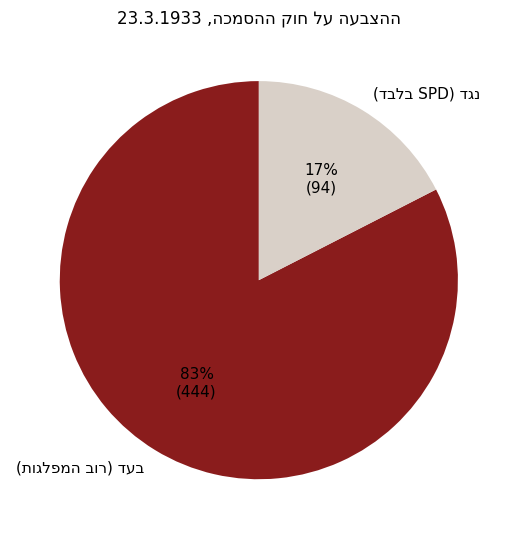

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
sizes = [444, 94]
labels_pie = [he('בעד (רוב המפלגות)'), he('נגד (SPD בלבד)')]
colors_pie = [PALETTE['red'], '#d9d0c8']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels_pie, autopct=lambda p: f'{p:.0f}%\n({int(round(p/100*sum(sizes)))})',
    colors=colors_pie, startangle=90, textprops={'fontsize': 11}
)
ax.set_title(he('ההצבעה על חוק ההסמכה, 23.3.1933'))
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## 4. החולצות החומות (SA — Sturmabteilung)

ה-**SA** ("חיל הסער"), המוכרים בכינוי "החולצות החומות", היה הכוח המיליטנטי־למחצה של המפלגה הנאצית — מאות אלפי גברים חמושים שתפקידם היה **טרור רחוב**: התנגשויות אלימות עם קומוניסטים וסוציאל-דמוקרטים, הפחדת בוחרים, ואכיפת המדיניות הנאצית מחוץ למסגרת החוק הרשמית.

פעולה מרכזית של ה-SA הייתה **החרם על עסקים יהודיים** ב-**1 באפריל 1933** — אנשי SA עמדו מול חנויות, משרדי עורכי דין ומרפאות בבעלות יהודית, צבעו עליהם מגן דוד וסיסמאות, ומנעו פיזית מלקוחות להיכנס. זו הייתה הפעולה הפומבית הראשונה נגד יהודי גרמניה מטעם המדינה — סימן מקדים למה שיבוא.

עד 1934 מנה ה-SA כ-**3 מיליון איש** — גדול משמעותית מהצבא הגרמני הרשמי (הוורמאכט), עובדה שהדאיגה מאוד את מפקדי הצבא ואת היטלר עצמו.


</div>

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## 5. ליל הסכינים הארוכות — 30 ביוני–2 ביולי 1934

הגודל וההשפעה של ה-SA הפכו לאיום על היטלר עצמו: מפקד ה-SA, **ארנסט רוהם**, שאף להפוך את הארגון לצבא מהפכני חדש שיבלע את הוורמאכט. מפקדי הצבא איימו שלא יתמכו בהיטלר כממשיכו של הינדנבורג (שהיה חולה וקרוב למותו) אלא אם כן יבלום את רוהם.

בין ה-30 ביוני ל-2 ביולי 1934, ה-**SS** (חיל השמירה האישי של היטלר, שהחל כזרוע קטנה בתוך ה-SA) ביצע **טיהור דמים**: רצח את רוהם ואת מרבית ההנהגה הבכירה של ה-SA, וכן יריבים פוליטיים ישנים שלא היה להם קשר ל-SA כלל.

**התוצאה:** ה-SA נותר קיים אך נטול כוח פוליטי, ה-SS הפך לזרוע הביטחונית המרכזית והאכזרית של המשטר, והצבא — מרוצה מסילוק האיום — נשבע נאמנות אישית להיטלר לאחר מות הינדנבורג בחודש הבא.

<div style="background:#f6f1ea; padding:10px 14px; border-radius:8px; border-right:4px solid #b8860b; margin-top:10px;"><b>נקודה למחשבה:</b> טיהור אלים נגד "אנשי שלו" חיזק את היטלר, לא החליש אותו. למה בעצם?</div>


</div>

In [5]:
q2 = widgets.RadioButtons(
    options=[
        he('כי הצבא איבד את האמון בהיטלר לגמרי'),
        he('כי הצבא ראה בכך הוכחה שהיטלר מוכן לשמור על סדר ולסלק איום פנימי, ותמך בו'),
        he('כי ה-SA השתלט על השלטון במקום היטלר'),
    ],
    layout=widgets.Layout(width='650px'),
    style={'description_width': '0px'}
)
btn2 = widgets.Button(description=he('בדוק תשובה'))
out2 = widgets.Output()

def check2(b):
    with out2:
        clear_output()
        if q2.index == 1:
            display(HTML('<div dir="rtl" style="color:#1a6b1a; font-weight:bold;">נכון. מבחינת הצבא, סילוק רוהם הסיר איום ממשי — ובתמורה, הצבא נתן להיטלר את הלגיטימציה שהיה זקוק לה.</div>'))
        else:
            display(HTML('<div dir="rtl" style="color:#8a1c1c; font-weight:bold;">לא מדויק — חשבו: מי הרוויח פוליטית מהטיהור הזה, ולמה הצבא היה מרוצה?</div>'))

btn2.on_click(check2)
display(q2, btn2, out2)


RadioButtons(layout=Layout(width='650px'), options=('ירמגל רלטיהב ןומאה תא דביא אבצה יכ', 'וב ךמתו ,ימינפ םויא…

Button(description='הבושת קודב', style=ButtonStyle())

Output()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## 6. ליל הבדולח — 9–10 בנובמבר 1938

**ליל הבדולח** (Kristallnacht, על שם רסיסי הזכוכית שכיסו את הרחובות) היה פוגרום שאורגן ובוצע ברחבי גרמניה ואוסטריה, ביוזמת המשטר הנאצי, בתגובה (המדומה) לרצח דיפלומט גרמני בפריז בידי יהודי צעיר. למעשה, זה היה שלב מתוכנן בהסלמה השיטתית נגד יהודי גרמניה.

הגרף הבא מציג כמה מהנתונים המתועדים של אותו לילה ושל הימים שאחריו:


</div>

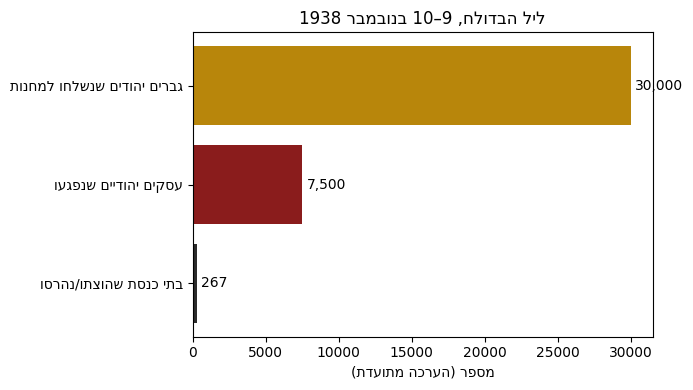

In [6]:
stats = {
    he('בתי כנסת שהוצתו/נהרסו'): 267,
    he('עסקים יהודיים שנפגעו'): 7500,
    he('גברים יהודים שנשלחו למחנות'): 30000,
}

fig, ax = plt.subplots(figsize=(7, 4))
names = list(stats.keys())
vals = list(stats.values())
bars = ax.barh(names, vals, color=[PALETTE['dark'], PALETTE['red'], PALETTE['gold']])
for b, v in zip(bars, vals):
    ax.text(v + max(vals)*0.01, b.get_y() + b.get_height()/2, f"{v:,}", va='center', fontsize=10)
ax.set_xlabel(he('מספר (הערכה מתועדת)'))
ax.set_title(he('ליל הבדולח, 9–10 בנובמבר 1938'))
plt.tight_layout()
plt.show()

display(HTML('<div dir="rtl" style="text-align:right;">בנוסף לנתונים אלה, נרצחו באותו הלילה עשרות יהודים — והאירוע היווה נקודת מפנה: מכאן ואילך המדיניות כלפי יהודי גרמניה עברה מהדרה והשפלה שיטתית, לאלימות פיזית גלויה שאורגנה ישירות בידי המדינה.</div>'))


<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## ציר הזמן האינטראקטיבי

הזיזו את הסליידר כדי לעבור בין האירועים המרכזיים ולראות היכן הם ממוקמים על ציר הזמן.


</div>

In [7]:
timeline_events = [
    ("30.1.1933", "היטלר ממונה לקנצלר גרמניה על ידי הנשיא הינדנבורג."),
    ("27.2.1933", "שריפת הרייכסטג — ולמחרת, צו חירום המשעה זכויות אזרח."),
    ("5.3.1933", "בחירות לרייכסטאג תחת טרור פוליטי — הנאצים מקבלים 43.9%."),
    ("23.3.1933", "חוק ההסמכה מעניק להיטלר סמכות לחוקק ללא הרייכסטג."),
    ("1.4.1933", "ה-SA מארגן חרם אלים על עסקים יהודיים ברחבי גרמניה."),
    ("30.6.1934", "ליל הסכינים הארוכות — טיהור מנהיגות ה-SA, התחזקות ה-SS."),
    ("15.9.1935", "חוקי נירנברג שוללים אזרחות גרמנית מיהודים."),
    ("9.11.1938", "ליל הבדולח — פוגרום ארצי מאורגן נגד יהודי גרמניה."),
    ("1.9.1939", "פלישה לפולין — פרוץ מלחמת העולם השנייה."),
]

event_slider = widgets.SelectionSlider(
    options=[e[0] for e in timeline_events],
    value=timeline_events[0][0],
    description=he('תאריך:'),
    continuous_update=False,
    layout=widgets.Layout(width='600px'),
    style={'description_width': '80px'}
)
out_tl = widgets.Output()

def draw_timeline(change=None):
    with out_tl:
        clear_output(wait=True)
        idx = [e[0] for e in timeline_events].index(event_slider.value)
        fig, ax = plt.subplots(figsize=(9, 2.2))
        xs = list(range(len(timeline_events)))
        ax.plot(xs, [0]*len(xs), color='#cfcfcf', zorder=1, linewidth=2)
        colors = [PALETTE['red'] if i == idx else ('#8a1c1c55' if i < idx else '#cfcfcf') for i in range(len(xs))]
        sizes = [220 if i == idx else 90 for i in range(len(xs))]
        ax.scatter(xs, [0]*len(xs), s=sizes, color=colors, zorder=2, edgecolor='black', linewidth=0.5)
        for i, (date, _) in enumerate(timeline_events):
            ax.text(i, 0.28 if i % 2 == 0 else -0.38, he(date), ha='center', fontsize=8, rotation=0)
        ax.set_ylim(-1, 1)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

        date, desc = timeline_events[idx]
        display(HTML(f'''<div dir="rtl" style="text-align:right; background:#f6f1ea; padding:12px 16px; border-radius:8px; border-right:4px solid {PALETTE["red"]}; font-size:1.05rem;">
        <b>{he(date)}</b> &nbsp;—&nbsp; {desc}</div>'''))

event_slider.observe(draw_timeline, names='value')
display(event_slider, out_tl)
draw_timeline()


SelectionSlider(continuous_update=False, description=':ךיראת', layout=Layout(width='600px'), options=('30.1.19…

Output()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


## בוחן סיכום

ענו על השאלות הבאות ולחצו על "בדוק את כל התשובות" בסוף כדי לראות את הציון שלכם.


</div>

In [8]:
quiz = [
    {
        'q': he('מי מינה את היטלר לתפקיד קנצלר גרמניה?'),
        'options': [he('הרייכסטג בהצבעה ישירה'), he('הנשיא פאול פון הינדנבורג'), he('העם הגרמני במשאל עם')],
        'correct': 1,
    },
    {
        'q': he('מה אפשר חוק ההסמכה?'),
        'options': [he('לממשלת היטלר לחוקק בלי אישור הרייכסטג'), he('בחירות חופשיות נוספות'), he('פירוק המפלגה הנאצית')],
        'correct': 0,
    },
    {
        'q': he('מי היה הקורבן העיקרי של "ליל הסכינים הארוכות"?'),
        'options': [he('הנהגת ה-SA, ובראשה ארנסט רוהם'), he('הנהגת ה-SS'), he('הנהגת המפלגה הקומוניסטית בלבד')],
        'correct': 0,
    },
    {
        'q': he('מה קרה בליל הבדולח?'),
        'options': [he('חתימת חוזה שלום עם צרפת'), he('פוגרום מאורגן נגד יהודי גרמניה'), he('פירוק ה-SA')],
        'correct': 1,
    },
]

quiz_widgets = []
for item in quiz:
    rb = widgets.RadioButtons(options=item['options'], layout=widgets.Layout(width='650px'), style={'description_width': '0px'})
    quiz_widgets.append(rb)
    display(HTML(f'<div dir="rtl" style="text-align:right; font-weight:bold; margin-top:14px;">{item["q"]}</div>'))
    display(rb)

btn_final = widgets.Button(description=he('בדוק את כל התשובות'), button_style='success')
out_final = widgets.Output()

def check_final(b):
    with out_final:
        clear_output()
        score = 0
        for rb, item in zip(quiz_widgets, quiz):
            if rb.index == item['correct']:
                score += 1
        color = '#1a6b1a' if score == len(quiz) else (PALETTE['gold'] if score >= len(quiz)//2 else PALETTE['red'])
        display(HTML(f'<div dir="rtl" style="text-align:right; font-size:1.2rem; font-weight:bold; color:{color};">הציון שלכם: {score} מתוך {len(quiz)}</div>'))

btn_final.on_click(check_final)
display(btn_final, out_final)


RadioButtons(layout=Layout(width='650px'), options=('הרישי העבצהב גטסכיירה', 'גרובנדניה ןופ לואפ אישנה', 'םע ל…

RadioButtons(layout=Layout(width='650px'), options=('גטסכיירה רושיא ילב קקוחל רלטיה תלשממל', 'תופסונ תוישפוח ת…

RadioButtons(layout=Layout(width='650px'), options=('םהור טסנרא השארבו ,SA-ה תגהנה', 'SS-ה תגהנה', 'דבלב תיטסי…

RadioButtons(layout=Layout(width='650px'), options=('תפרצ םע םולש הזוח תמיתח', 'הינמרג ידוהי דגנ ןגרואמ םורגופ…

Button(button_style='success', description='תובושתה לכ תא קודב', style=ButtonStyle())

Output()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI',Arial,sans-serif; line-height:1.7;">


---
## להעמקה

הנתונים במחברת זו מבוססים על עובדות היסטוריות מוסכמות ומתועדות היטב (מספרי בחירות, תוצאות הצבעות פרלמנטריות, אירועים מתוארכים). למי שרוצה להעמיק, מומלץ לחפש חומרים באתרי **יד ושם**, **המוזיאון הלאומי לתולדות השואה בוושינגטון (USHMM)**, ומרכזי מחקר אקדמיים המתמחים בתקופת גרמניה הנאצית.

*מחברת זו נוצרה כדוגמה לשיעור היסטוריה אינטראקטיבי — אינה תחליף ללימוד מעמיק יותר עם מורה או חומרי מקור.*


</div>